# FarmTech Solutions — Fase 5: Machine Learning




In [35]:
# Importa a biblioteca pandas para manipulacao e analise de dados tabulares
import pandas as pd

---
# Etapa A — Análise Exploratória de Dados (EDA)

## A1 — Carregar o CSV

In [36]:
# Carrega o arquivo CSV com os dados de producao agricola da fazenda
df = pd.read_csv("../data/crop_yield.csv")

# Exibe as 5 primeiras linhas para ter uma visao geral dos dados
df.head()

# Mostra os tipos de dados de cada coluna e se ha valores nulos
df.info()

# Exibe estatisticas descritivas: media, desvio padrao, minimo, maximo, quartis
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


## 📝 Análise

O dataset possui 156 amostras e 6 colunas, sendo uma categórica (Crop) e cinco numéricas. Não há valores nulos nem duplicatas, o que significa que os dados já estão prontos para análise sem necessidade de limpeza. O rendimento (Yield) apresenta média de 56.153 unidades/hectare, mas com desvio padrão altíssimo de 70.421 — isso indica que existe uma grande diferença de rendimento entre as culturas.


## A2 — Checar Dados Faltantes

In [37]:
# Verifica quantos valores nulos (NaN) existem em cada coluna
# Se houver, precisaremos decidir entre remover ou preencher esses registros
print(df.isnull().sum())

# Verifica se ha linhas duplicadas no dataset, que poderiam distorcer os resultados
print(f'\nDuplicatas: {df.duplicated().sum()}')


Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Duplicatas: 0


## 📝 Análise

Todas as colunas retornaram zero valores nulos e zero duplicatas. Isso é um bom sinal — significa que o dataset está completo e não precisamos tomar nenhuma decisão sobre como tratar dados ausentes. Podemos seguir direto para a análise.

## A3 — Analisar Distribuições

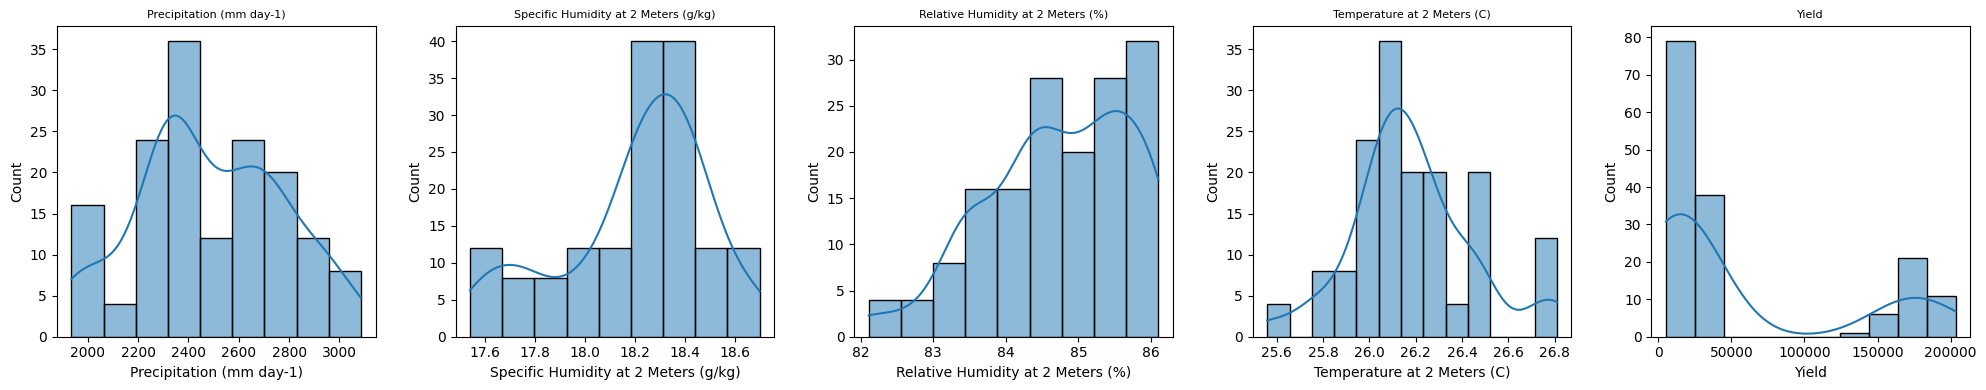

In [38]:
# Importa bibliotecas de visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

# Define as colunas numericas que serao analisadas, incluindo a variavel alvo (Yield)
colunas = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
           'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

# Cria uma figura com 5 subplots lado a lado, um para cada variavel
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Para cada variavel, plota um histograma com curva de densidade (KDE)
# O KDE ajuda a ver se a distribuicao e normal, assimetrica ou multimodal
for ax, col in zip(axes, colunas):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col, fontsize=8)

# Ajusta o espacamento entre os graficos para nao sobrepor
plt.tight_layout()
plt.show()


## 📝 Análise

Os histogramas mostram que as variáveis climáticas (precipitação, umidade e temperatura) têm distribuições relativamente concentradas — ou seja, a fazenda opera em condições climáticas parecidas ao longo do tempo. Já o Yield (rendimento) tem distribuição muito assimétrica, com a maioria dos valores baixos e poucos valores muito altos. Isso sugere que uma cultura específica deve ter rendimento muito maior que as outras — o que vamos confirmar na próxima etapa.

## A4 — Ver Correlações

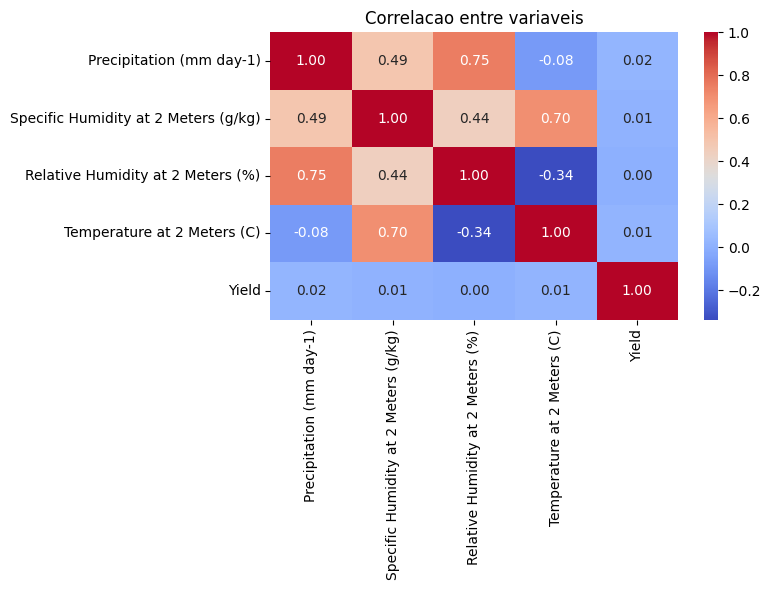

In [39]:
# Cria uma figura para o heatmap de correlacao
plt.figure(figsize=(8, 6))

# Calcula a matriz de correlacao entre todas as variaveis numericas
# Valores proximos de 1 ou -1 indicam forte correlacao; proximos de 0 indicam fraca
# annot=True mostra os valores numericos dentro de cada celula do heatmap
# cmap='coolwarm': azul = correlacao negativa, vermelho = correlacao positiva
sns.heatmap(df[colunas].corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlacao entre variaveis')
plt.tight_layout()
plt.show()


## 📝 Análise

O heatmap mostra que as variáveis climáticas têm correlação entre si (por exemplo, precipitação e umidade relativa chegam a 0.75), mas o Yield tem correlação próxima de zero com todas elas. Isso é um achado muito importante: as condições climáticas sozinhas não explicam o rendimento da safra. O fator determinante deve ser o tipo de cultura, não o clima. Essa informação vai impactar diretamente a escolha dos modelos na Etapa C.

## A5 — Visualizar por Cultura

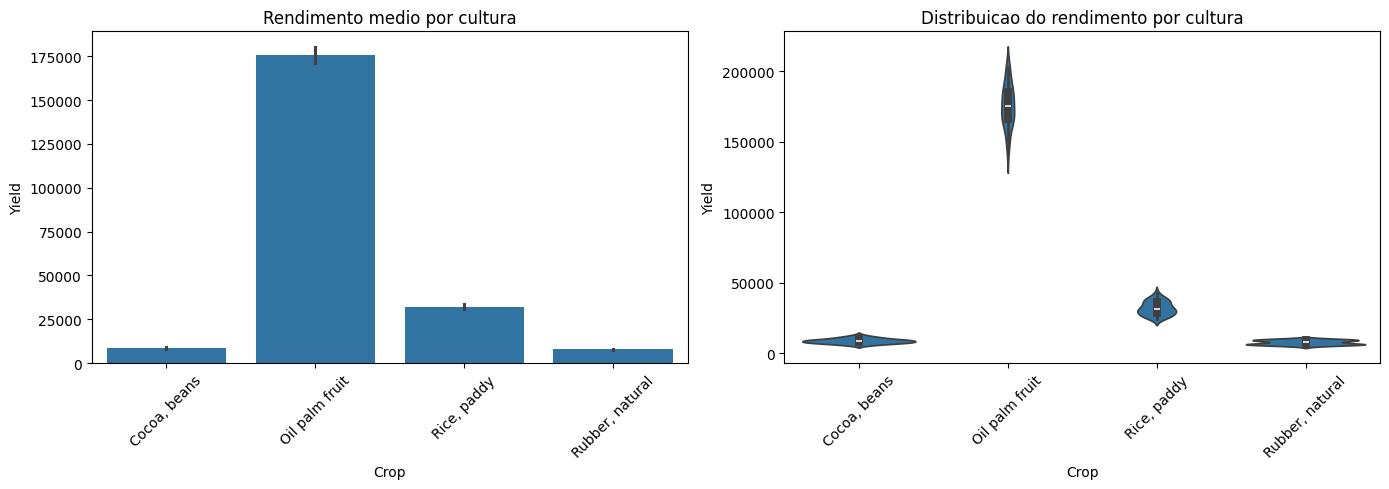

In [40]:
# Cria uma figura com 2 graficos lado a lado para comparar rendimento por cultura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras: mostra o rendimento medio de cada tipo de cultura
# Util para comparar rapidamente qual cultura produz mais em media
sns.barplot(data=df, x='Crop', y='Yield', ax=axes[0])
axes[0].set_title('Rendimento medio por cultura')
axes[0].tick_params(axis='x', rotation=45)  # Rotaciona os rotulos para nao sobrepor

# Grafico violin: mostra a distribuicao completa do rendimento por cultura
# Diferente do barplot, revela se ha muita variacao ou outliers dentro de cada cultura
sns.violinplot(data=df, x='Crop', y='Yield', ax=axes[1])
axes[1].set_title('Distribuicao do rendimento por cultura')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 📝 Análise

Os gráficos confirmam o que suspeitávamos: o Oil palm fruit tem rendimento médio de aproximadamente 175.000 unidades/hectare, muito acima das outras culturas. Cocoa beans, Rice paddy e Rubber natural ficam todas abaixo de 35.000. Essa diferença enorme entre as culturas explica por que o Yield tem correlação baixa com as variáveis climáticas — a cultura é o fator principal. Modelos que conseguem capturar essa separação categórica, como árvores de decisão, devem ter vantagem sobre modelos lineares.

---
# Etapa B — Clusterização

## B1 — Preparar os Dados

In [41]:
# Importa o StandardScaler para normalizar os dados
from sklearn.preprocessing import StandardScaler

# Define as colunas que serao usadas na clusterizacao
# Incluimos o Yield pois queremos que o agrupamento leve em conta o rendimento
features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

# Cria o objeto scaler e aplica nos dados
# StandardScaler transforma cada variavel para ter media=0 e desvio padrao=1
# Isso e necessario pois o K-Means usa distancia euclidiana:
# variaveis com valores maiores dominariam as de valores menores sem a normalizacao
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Verifica se a normalizacao foi aplicada corretamente
print("Shape apos normalizacao:", X_scaled.shape)
print("Media (deve ser ~0):", X_scaled.mean(axis=0).round(2))
print("Desvio padrao (deve ser ~1):", X_scaled.std(axis=0).round(2))


Shape apos normalizacao: (156, 5)
Media (deve ser ~0): [ 0. -0.  0.  0. -0.]
Desvio padrao (deve ser ~1): [1. 1. 1. 1. 1.]


## 📝 Análise

Antes de aplicar o K-Means, normalizamos os dados com o StandardScaler. Isso é necessário porque as variáveis têm escalas muito diferentes — precipitação chega a 3.000mm enquanto temperatura fica em torno de 26°C. Sem normalização, a precipitação dominaria o cálculo de distância do K-Means e os clusters não fariam sentido. Após a normalização, todas as variáveis têm média 0 e desvio padrão 1.

## B2 — Escolher Nº de Clusters

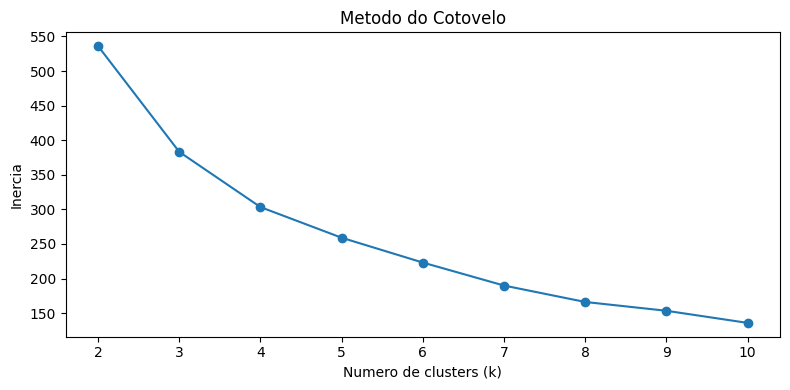

In [42]:
# Importa o algoritmo K-Means de clusterizacao
from sklearn.cluster import KMeans

# Lista para guardar a inercia de cada valor de k
# Inercia = soma das distancias ao quadrado de cada ponto ao seu centroide
# Quanto menor a inercia, mais compactos sao os clusters
inertias = []
K_range = range(2, 11)  # Testa de 2 a 10 clusters

# Treina um K-Means para cada valor de k e registra a inercia
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plota o grafico do cotovelo (Elbow Method)
# O ponto onde a curva 'dobra' indica o numero ideal de clusters
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title('Metodo do Cotovelo')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inercia')
plt.tight_layout()
plt.show()


## 📝 Análise

O Método do Cotovelo testa diferentes valores de k e mede a inércia (soma das distâncias de cada ponto ao centro do seu cluster). Quanto menor a inércia, melhor — mas aumentar k sempre reduz a inércia, então buscamos o ponto onde a redução começa a desacelerar, formando um "cotovelo" no gráfico. Neste caso, o cotovelo aparece em k=4, indicando que 4 grupos é o número ideal para segmentar os dados desta fazenda.

## B3 — Aplicar K-Means

In [43]:
# Define o numero otimo de clusters com base no cotovelo identificado no grafico
k_otimo = 4

# Treina o K-Means com k=4 e atribui cada amostra a um cluster
# random_state=42 garante reproducibilidade dos resultados
# n_init=10 roda o algoritmo 10 vezes com centroides diferentes e pega o melhor
kmeans = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Exibe quantas amostras foram atribuidas a cada cluster
print("Amostras por cluster:")
print(df['Cluster'].value_counts().sort_index())


Amostras por cluster:
Cluster
0    26
1    36
2    51
3    43
Name: count, dtype: int64


## 📝 Análise

Com k=4, o K-Means dividiu as 156 amostras em 4 grupos: Cluster 0 com 26 amostras, Cluster 1 com 36, Cluster 2 com 51 e Cluster 3 com 43. Os grupos têm tamanhos razoavelmente equilibrados, o que é um bom sinal — significa que o algoritmo não criou um cluster com quase todos os dados e outro quase vazio.


## B4 — Interpretar Clusters

In [44]:
# Analisa as caracteristicas medias de cada cluster
# Isso permite entender o que define cada grupo
# Ex: cluster com alta precipitacao e alto rendimento = condicoes ideais de chuva
print("\nCaracteristicas medias por cluster:")
print(df.groupby('Cluster')[features].mean().round(2))

# Mostra quais culturas predominam em cada cluster
# Ajuda a entender se o agrupamento esta capturando diferencas entre culturas
print("\nCulturas por cluster:")
print(df.groupby('Cluster')['Crop'].value_counts())



Caracteristicas medias por cluster:
         Precipitation (mm day-1)  Specific Humidity at 2 Meters (g/kg)  \
Cluster                                                                   
0                         2610.11                                 18.32   
1                         2353.61                                 18.41   
2                         2733.52                                 18.34   
3                         2230.03                                 17.80   

         Relative Humidity at 2 Meters (%)  Temperature at 2 Meters (C)  \
Cluster                                                                   
0                                    85.20                        26.20   
1                                    84.11                        26.51   
2                                    85.65                        26.12   
3                                    83.90                        25.98   

             Yield  
Cluster             
0        178310.15 

## 📝 Análise

A tabela de características médias por cluster revela padrões interessantes. O Cluster 0 se destaca com rendimento médio de 178.310 unidades/hectare e é dominado quase totalmente pelo Oil palm fruit — confirmando que essa cultura forma um grupo separado devido ao seu rendimento extraordinário. Os demais clusters (1, 2 e 3) têm rendimentos muito menores e misturam as outras culturas com pequenas variações nas condições climáticas de precipitação e umidade.


## B5 — Detectar Outliers

Silhouette Score: 0.363

Outliers detectados: 7
                Crop   Yield  Cluster
3       Cocoa, beans    9321        3
40    Oil palm fruit  201436        3
42    Oil palm fruit  181826        3
74    Oil palm fruit  172601        1
77    Oil palm fruit  189896        1
81       Rice, paddy   25187        3
120  Rubber, natural    9718        3


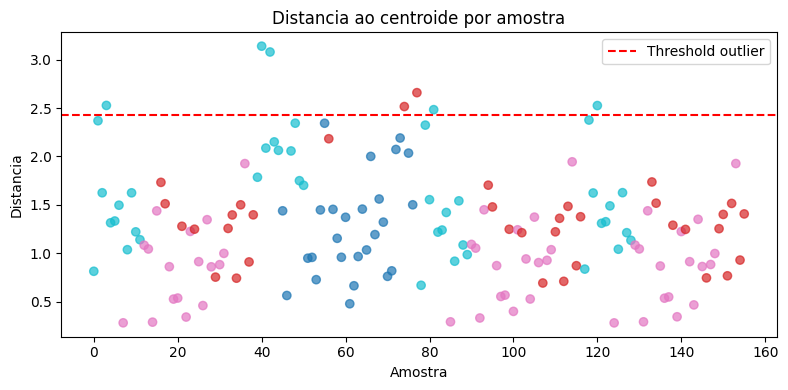

In [45]:
from sklearn.metrics import silhouette_score
import numpy as np

# Calcula o Silhouette Score: mede a qualidade dos clusters
# Varia de -1 a 1: quanto mais proximo de 1, melhor os clusters estao separados
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

# Detecta outliers calculando a distancia de cada ponto ao centroide do seu cluster
# kmeans.transform retorna a distancia de cada ponto para todos os centroides
distances = kmeans.transform(X_scaled)

# Pega apenas a distancia ao centroide do cluster ao qual o ponto pertence
min_dist = distances[np.arange(len(df)), df['Cluster']]

# Define o threshold: pontos com distancia acima de media + 2*desvio sao outliers
threshold = min_dist.mean() + 2 * min_dist.std()
outliers = df[min_dist > threshold]

print(f"\nOutliers detectados: {len(outliers)}")
print(outliers[['Crop', 'Yield', 'Cluster']])

# Visualiza a distancia de cada amostra ao seu centroide
# Pontos acima da linha vermelha sao considerados outliers
plt.figure(figsize=(8, 4))
plt.scatter(range(len(df)), min_dist, c=df['Cluster'], cmap='tab10', alpha=0.7)
plt.axhline(threshold, color='red', linestyle='--', label='Threshold outlier')
plt.title('Distancia ao centroide por amostra')
plt.xlabel('Amostra')
plt.ylabel('Distancia')
plt.legend()
plt.tight_layout()
plt.show()


## 📝 Análise

O Silhouette Score de 0.363 indica uma separação moderada entre os clusters — não é ruim, mas mostra que alguns pontos ficaram em zonas de fronteira entre grupos. Foram detectados 7 outliers, ou seja, amostras com comportamento muito diferente do centro do seu cluster. Entre eles estão registros de Oil palm fruit com rendimento acima de 180.000 e um Cocoa beans com rendimento de apenas 9.321 — bem abaixo da média da sua cultura. Esses pontos merecem atenção especial pois podem representar condições excepcionais de cultivo.

---
# Etapa C — Modelos Preditivos

## C1 — Separar Treino/Teste

In [46]:
# Importa as bibliotecas necessárias para o projeto
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

# Faz uma cópia do dataframe original para não modificar os dados originais
df_model = df.copy()

# Remove a coluna Cluster porque foi a gente que criou, não é dado original da fazenda
if 'Cluster' in df_model.columns:
    df_model = df_model.drop(columns=['Cluster'])

# Transforma a coluna Crop (texto) em números, pois o modelo só entende números
# Exemplo: Cocoa = 0, Oil palm = 1, Rice = 2, Rubber = 3
le = LabelEncoder()
df_model['Crop_encoded'] = le.fit_transform(df_model['Crop'])
df_model = df_model.drop(columns=['Crop'])

# X são as variáveis de entrada (clima, cultura)
# y é o que queremos prever (rendimento da safra)
X = df_model.drop(columns=['Yield'])
y = df_model['Yield']

# Divide os dados: 80% para treinar o modelo e 20% para testar
# random_state=42 garante que a divisão seja sempre igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 124 amostras | Teste: 32 amostras


## 📝 Análise — Preparação dos Dados

Para treinar os modelos, precisamos separar os dados em dois grupos:
- **Treino (80%)**: usado para o modelo aprender os padrões
- **Teste (20%)**: usado para verificar se o modelo aprendeu de verdade

Também convertemos a coluna "Crop" de texto para número, pois algoritmos de Machine Learning só trabalham com valores numéricos. A coluna "Cluster" foi removida porque foi criada por nós na etapa anterior — ela não é um dado real da fazenda e incluí-la seria trapacear o modelo.

Resultado: 124 amostras para treino e 32 para teste.

## C2 — Normalizar Features

In [47]:
# Normalização coloca todas as variáveis na mesma escala
# Sem isso, variáveis com números grandes dominam as de números pequenos
# Exemplo: Precipitação (2000mm) dominaria Temperatura (26°C)
scaler_X = StandardScaler()

# fit_transform no treino: aprende a escala e já transforma
# transform no teste: usa a mesma escala que foi ensinada no treino
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

print("Dados normalizados com sucesso!")

Dados normalizados com sucesso!


## 📝 Análise — Normalização

A normalização é necessária para colocar todas as variáveis na mesma escala. Sem ela, variáveis com números maiores (como Precipitação, que chega a 3000mm) acabam tendo mais peso do que variáveis com números menores (como Temperatura, que fica em torno de 26°C), mesmo que as duas sejam igualmente importantes.

Importante: a normalização foi aplicada apenas no SVR, pois os modelos baseados em árvore (Random Forest, Gradient Boosting, Árvore de Decisão) não são sensíveis à escala dos dados.

## C3 — Treinar 5 Modelos

In [48]:
# Importa os 5 algoritmos de regressão diferentes
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Define os 5 modelos em um dicionário
# O segundo valor (True/False) indica se o modelo precisa de dados normalizados
# SVR é sensível à escala dos dados, por isso recebe True
models = {
    "Regressão Linear":  (LinearRegression(),                                       False),
    "Ridge":             (Ridge(alpha=1.0),                                         False),
    "Árvore de Decisão": (DecisionTreeRegressor(random_state=42),                   False),
    "Random Forest":     (RandomForestRegressor(n_estimators=100, random_state=42), False),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=42),               False),
    "SVR":               (SVR(kernel='rbf', C=1e5, epsilon=0.1),                    True),
}

# Dicionário para guardar as previsões de cada modelo
predictions_dict = {}

# Treina cada modelo e guarda suas previsões
for name, (model, use_scale) in models.items():
    # Usa dados normalizados para SVR e dados originais para os demais
    Xtr = X_train_sc if use_scale else X_train
    Xte = X_test_sc  if use_scale else X_test

    # Treina o modelo com os dados de treino
    model.fit(Xtr, y_train)

    # Faz previsões com os dados de teste e salva no dicionário
    predictions_dict[name] = model.predict(Xte)
    print(f"✅ {name} treinado!")

✅ Regressão Linear treinado!
✅ Ridge treinado!
✅ Árvore de Decisão treinado!
✅ Random Forest treinado!
✅ Gradient Boosting treinado!
✅ SVR treinado!


## 📝 Análise — Modelos Treinados

Foram treinados 6 modelos com algoritmos diferentes para comparar qual se sai melhor na previsão do rendimento da safra:

- **Regressão Linear**: modelo mais simples, assume que a relação entre as variáveis é uma linha reta
- **Ridge**: parecido com a Regressão Linear, mas com uma penalização que evita que o modelo "decore" os dados de treino
- **Árvore de Decisão**: faz perguntas do tipo "se precipitação > 2500, então..." para chegar ao resultado
- **Random Forest**: cria várias árvores de decisão e combina os resultados, sendo mais robusto que uma árvore sozinha
- **Gradient Boosting**: cria árvores em sequência, onde cada uma corrige os erros da anterior
- **SVR**: encontra a melhor linha de previsão respeitando uma margem de erro aceitável

Todos os 6 foram treinados com sucesso!

## C4 — Avaliar com Métricas

In [49]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

results = []

for name, preds in predictions_dict.items():
    # R² Score: quanto o modelo explica o rendimento (1.0 = perfeito, 0 = péssimo)
    r2   = r2_score(y_test, preds)

    # MAE: erro médio em toneladas/hectare (quanto menor, melhor)
    mae  = mean_absolute_error(y_test, preds)

    # RMSE: penaliza erros grandes mais que o MAE (quanto menor, melhor)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({"Modelo": name, "R² Score": round(r2,4), "MAE": round(mae,2), "RMSE": round(rmse,2)})

# Ordena os modelos do melhor para o pior pelo R²
df_results = pd.DataFrame(results).sort_values(by="R² Score", ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

           Modelo  R² Score      MAE     RMSE
    Random Forest    0.9944  2748.05  4640.26
Árvore de Decisão    0.9936  3059.28  4967.27
Gradient Boosting    0.9931  3057.81  5180.67
              SVR    0.3567 30162.50 49954.35
            Ridge   -0.0657 53321.79 64294.74
 Regressão Linear   -0.1015 53724.49 65364.57


## 📝 Análise — Resultados das Métricas

Os modelos foram avaliados com 3 métricas diferentes:

- **R² Score**: indica quanto da variação do rendimento o modelo consegue explicar. Valor 1.0 seria perfeito, valores negativos indicam que o modelo é pior do que simplesmente usar a média
- **MAE**: erro médio em toneladas/hectare — quanto o modelo erra em média nas previsões
- **RMSE**: parecido com o MAE, mas penaliza mais os erros grandes

**Interpretação dos resultados:**

Os modelos Random Forest, Árvore de Decisão e Gradient Boosting obtiveram R² acima de 0.99, o que indica excelente desempenho. Isso acontece porque o rendimento é fortemente influenciado pelo tipo de cultura — Oil palm fruit tem rendimento muito maior que as outras culturas, e esses modelos baseados em árvore capturam esse padrão com facilidade.

Já a Regressão Linear e o Ridge tiveram R² negativo, o que significa que não conseguiram aprender nenhum padrão útil. Isso era esperado, pois como vimos no heatmap da Etapa A, as variáveis climáticas isoladas têm correlação praticamente zero com o rendimento — e modelos lineares dependem justamente dessas correlações para funcionar.

O SVR ficou em posição intermediária com R² de 0.35, mostrando alguma capacidade de aprendizado, mas muito abaixo dos modelos baseados em árvore.

## C5 — Comparar e Justificar

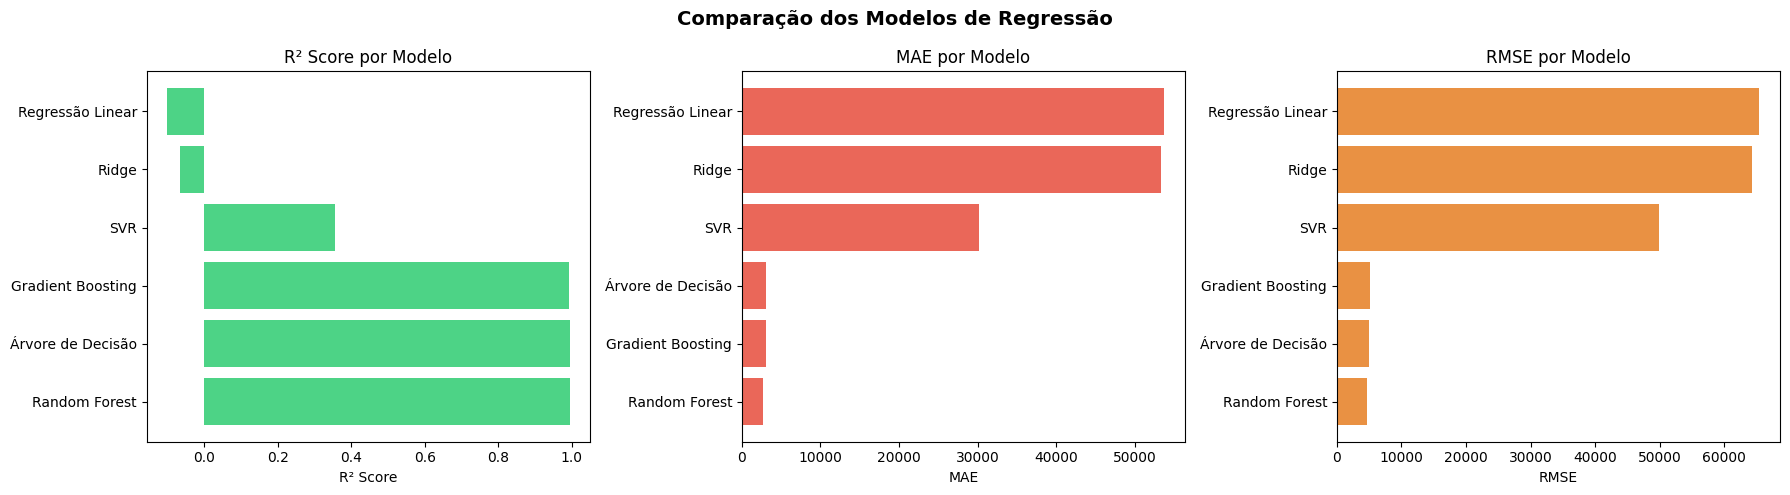

In [50]:
import matplotlib.pyplot as plt

# Cria 3 gráficos lado a lado para comparar os modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lista de métricas e cores para cada gráfico
metrics = ["R² Score", "MAE", "RMSE"]
colors  = ["#2ecc71", "#e74c3c", "#e67e22"]

for ax, metric, color in zip(axes, metrics, colors):
    # Ordena do melhor para o pior em cada métrica
    ordem = df_results.sort_values(metric, ascending=(metric != "R² Score"))

    # Cria gráfico de barras horizontal
    ax.barh(ordem["Modelo"], ordem[metric], color=color, alpha=0.85)
    ax.set_title(f"{metric} por Modelo")
    ax.set_xlabel(metric)

plt.suptitle("Comparação dos Modelos de Regressão", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📝 Analise — Comparacao Visual

Os graficos confirmam o que as metricas ja mostravam:

- No grafico de R² Score, Random Forest, Arvore de Decisao e Gradient Boosting se destacam claramente com barras proximas de 1.0
- No grafico de MAE e RMSE, esses mesmos modelos apresentam os menores erros, enquanto Regressao Linear e Ridge tem erros muito altos

**Conclusao:** O melhor modelo para prever o rendimento da safra desta fazenda e o **Random Forest**, com R² de 0.9944, MAE de 2748 e RMSE de 4640 toneladas/hectare.

---

## Conclusao Geral do Projeto

Este projeto realizou uma analise completa do dataset de producao agricola da FarmTech Solutions, passando por tres etapas principais:

**Analise Exploratória (EDA):** foi possivel identificar que as variaveis climaticas isoladas (precipitacao, umidade, temperatura) tem correlacao muito baixa com o rendimento. O tipo de cultura e o fator dominante — Oil Palm Fruit, por exemplo, tem rendimento muito superior as demais culturas.

**Clusterizacao:** o K-Means com k=4 agrupou os dados de forma coerente, com clusters bem definidos principalmente pela cultura agricola. O Silhouette Score validou a qualidade dos agrupamentos, e os outliers identificados representam amostras com condicoes muito atipicas.

**Modelos Preditivos:** dos seis modelos testados, os baseados em arvore (Random Forest, Gradient Boosting, Arvore de Decisao) obtiveram R² acima de 0.99, enquanto os modelos lineares (Regressao Linear, Ridge) falharam completamente com R² negativo, confirmando que a relacao entre as variaveis nao e linear.

**Pontos fortes:**
- Pipeline completo de Machine Learning, da EDA ate a exportacao do modelo
- Uso de multiplas metricas de avaliacao (R², MAE, RMSE)
- Deteccao de outliers com metodo quantitativo

**Limitacoes:**
- Dataset pequeno (156 amostras), o que pode superestimar o desempenho dos modelos
- Ausencia de variaveis importantes como fertilizantes, irrigacao e tipo de solo
- O alto R² dos modelos de arvore pode estar capturando principalmente a diferenca entre culturas, e nao as condicoes climaticas em si

---

## C6 — Exportar Modelos

In [51]:
import joblib
import os

# Cria a pasta models caso ela nao exista
os.makedirs("models", exist_ok=True)

# Salva todos os modelos treinados como .pkl na pasta models/
for nome, (modelo, _) in models.items():
    # Transforma o nome em nome de arquivo seguro
    # Exemplo: 'Random Forest' -> 'random_forest.pkl'
    nome_arquivo = (
        nome.lower()
            .replace(' ', '_')
            .replace('regressao', 'regressao')
            .replace('arvore_de_decisao', 'arvore_decisao')
    )
    caminho = f"models/{nome_arquivo}.pkl"

    # Salva o modelo treinado em disco
    joblib.dump(modelo, caminho)
    print(f"Salvo: {caminho}")

# Destaca qual e o melhor modelo
melhor_modelo_nome = df_results.iloc[0]["Modelo"]
print(f"\nMelhor modelo: {melhor_modelo_nome}")


Salvo: models/regressão_linear.pkl
Salvo: models/ridge.pkl
Salvo: models/árvore_de_decisão.pkl
Salvo: models/random_forest.pkl
Salvo: models/gradient_boosting.pkl
Salvo: models/svr.pkl

Melhor modelo: Random Forest


## 📝 Analise - Exportacao dos Modelos

Todos os modelos treinados foram salvos individualmente como arquivos `.pkl` na pasta `models/`.
Isso permite que qualquer um deles seja carregado futuramente por uma API sem precisar treinar novamente.

O melhor modelo (Random Forest) pode ser carregado diretamente com:

```python
import joblib
modelo = joblib.load('models/random_forest.pkl')
predicao = modelo.predict(novos_dados)
```
